# Hyperparameter Search Results

This notebook aggregates and plots the metrics from the weight hyperparameter search experiments.

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re

sns.set_theme(style="whitegrid")

In [3]:
def extract_weight(folder_name):
    match = re.search(r'w_([\d\.]+)_', folder_name)
    if match:
        return float(match.group(1))
    return None

results = []
base_dir = '../'

for folder in glob.glob(os.path.join(base_dir, 'w_*_jitter_32')):
    folder_name = os.path.basename(folder)
    weight = extract_weight(folder_name)
    
    summary_path = os.path.join(folder, 'test_metrics_summary.json')
    if os.path.exists(summary_path) and weight is not None:
        with open(summary_path, 'r') as f:
            metrics = json.load(f)
        
        metrics['weight'] = weight
        metrics['experiment'] = folder_name
        results.append(metrics)

df = pd.DataFrame(results)
df = df.sort_values('weight').reset_index(drop=True)

df.head()

,mean_profile_pearson(total>10),std_profile_pearson(total>10),mean_profile_pearson(total>50),std_profile_pearson(total>50),mean_profile_pearson(total>100),std_profile_pearson(total>100),mean_profile_pearson(total>200),std_profile_pearson(total>200),dlogodds_pearson,dlogodds_pearson(total>10),pi_pearson(total>10),dlogodds_pearson(total>50),pi_pearson(total>50),dlogodds_pearson(total>100),pi_pearson(total>100),dlogodds_pearson(total>200),pi_pearson(total>200),weight,experiment
0,0.652715,0.288573,0.692748,0.307073,0.655002,0.344753,0.584194,0.388898,0.481196,0.448000,0.319534,0.518587,0.251572,0.538711,0.151605,0.507225,0.111244,0.0,w_0.0_jitter_32
1,0.654444,0.287181,0.700333,0.296853,0.675254,0.326786,0.616512,0.371364,0.513351,0.480885,0.647740,0.569903,0.701156,0.608877,0.665342,0.567880,0.607502,1.0,w_1.0_jitter_32
2,0.655754,0.283108,0.705345,0.293171,0.674118,0.326267,0.609762,0.354058,0.501869,0.505996,0.808788,0.599355,0.858696,0.684329,0.877271,0.718973,0.896162,10.0,w_10.0_jitter_32
3,0.652184,0.285905,0.700820,0.290914,0.673266,0.318694,0.618134,0.349756,0.429973,0.484132,0.898421,0.575795,0.918668,0.667831,0.936712,0.728022,0.947481,30.0,w_30.0_jitter_32
4,0.638563,0.290470,0.691558,0.294445,0.658318,0.322520,0.593511,0.355605,0.448963,0.492784,0.861143,0.591078,0.909884,0.676747,0.941472,0.714925,0.956206,100.0,w_100.0_jitter_32


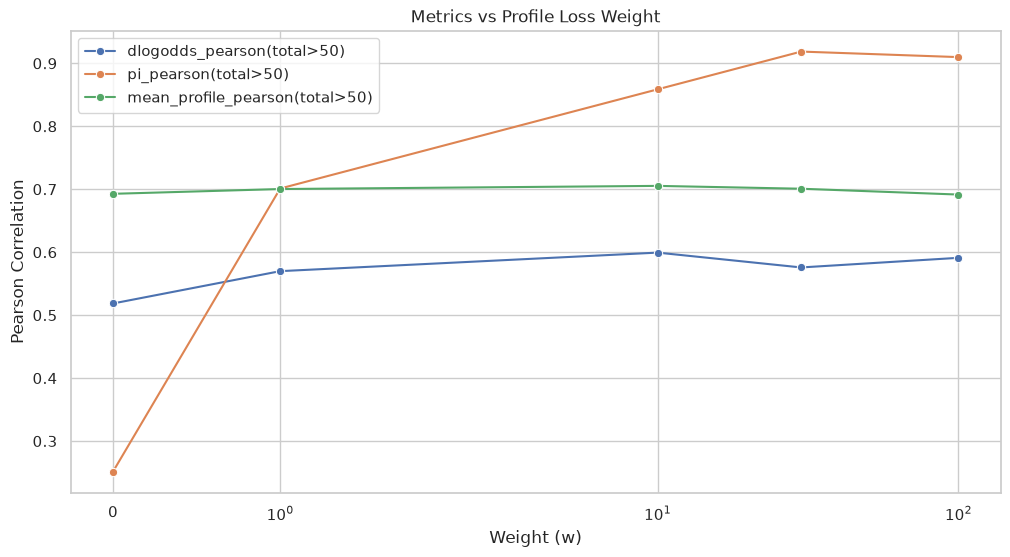

In [4]:
# Plotting overall metrics (e.g. Pearson correlation)
metrics_to_plot = [
    'dlogodds_pearson(total>50)',
    'pi_pearson(total>50)', 
    'mean_profile_pearson(total>50)'
]

plt.figure(figsize=(12, 6))

for metric in metrics_to_plot:
    if metric in df.columns:
        sns.lineplot(data=df, x='weight', y=metric, marker='o', label=metric)

plt.xscale('symlog')
plt.title('Metrics vs Profile Loss Weight')
plt.xlabel('Weight (w)')
plt.ylabel('Pearson Correlation')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

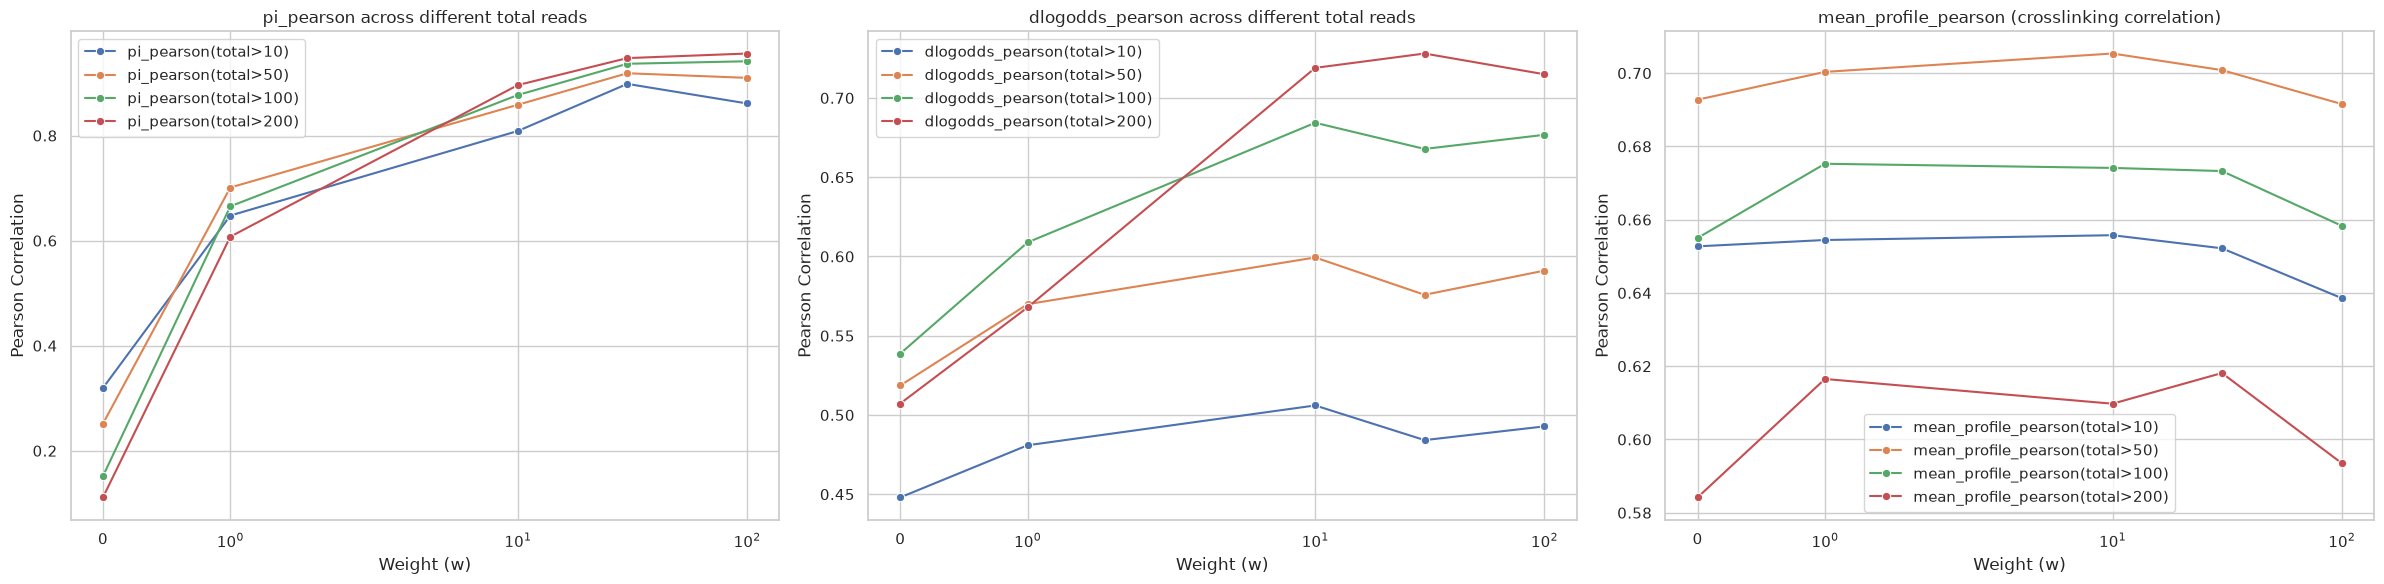

In [5]:
# Plotting all pearson correlations based on total reads
pi_pearson_cols = [col for col in df.columns if col.startswith("pi_pearson")]
dlogodds_pearson_cols = [col for col in df.columns if col.startswith("dlogodds_pearson(")]
mean_profile_pearson_cols = [col for col in df.columns if col.startswith("mean_profile_pearson(")]

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for col in pi_pearson_cols:
    sns.lineplot(data=df, x="weight", y=col, marker="o", label=col, ax=axes[0])
axes[0].set_xscale("symlog")
axes[0].set_title("pi_pearson across different total reads")
axes[0].set_xlabel("Weight (w)")
axes[0].set_ylabel("Pearson Correlation")
axes[0].grid(True, which="both", ls="-")

for col in dlogodds_pearson_cols:
    sns.lineplot(data=df, x="weight", y=col, marker="o", label=col, ax=axes[1])
axes[1].set_xscale("symlog")
axes[1].set_title("dlogodds_pearson across different total reads")
axes[1].set_xlabel("Weight (w)")
axes[1].set_ylabel("Pearson Correlation")
axes[1].grid(True, which="both", ls="-")

for col in mean_profile_pearson_cols:
    sns.lineplot(data=df, x="weight", y=col, marker="o", label=col, ax=axes[2])
axes[2].set_xscale("symlog")
axes[2].set_title("mean_profile_pearson (crosslinking correlation)")
axes[2].set_xlabel("Weight (w)")
axes[2].set_ylabel("Pearson Correlation")
axes[2].grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()


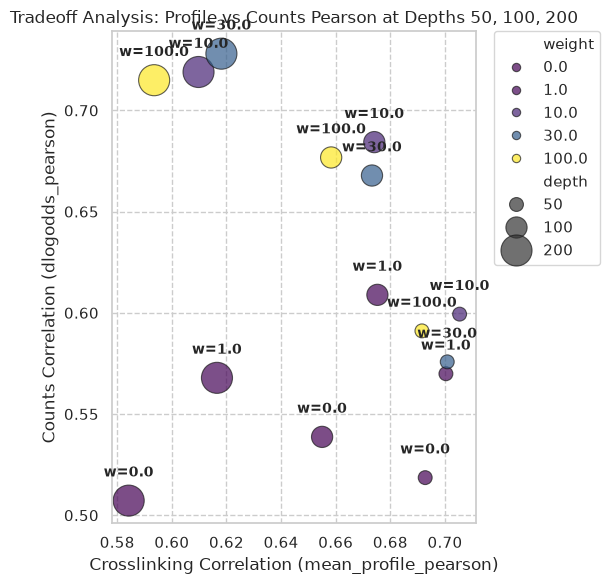

In [9]:
# Scatter plot to visualize the tradeoff at different read depths (50, 100, 200)
tradeoff_data = []
depths = [50, 100, 200]

for idx, row in df.iterrows():
    w = row["weight"]
    for d in depths:
        prof_col = f"mean_profile_pearson(total>{d})"
        count_col = f"dlogodds_pearson(total>{d})"
        if prof_col in row and count_col in row:
            tradeoff_data.append({
                "weight": w,
                "depth": d,
                "mean_profile_pearson": row[prof_col],
                "dlogodds_pearson": row[count_col]
            })

df_tradeoff = pd.DataFrame(tradeoff_data)

plt.figure(figsize=(6,6))

# Create scatter plot colored by weight and sized by depth
scatter = sns.scatterplot(
    data=df_tradeoff, 
    x="mean_profile_pearson", 
    y="dlogodds_pearson", 
    hue="weight", 
    size="depth",
    sizes=(100, 500),
    palette="viridis", 
    edgecolor="k",
    alpha=0.7
)

# Annotate each weight (using depth=50 points to avoid text clutter)
for depth, df_annot in df_tradeoff.groupby(by = 'depth'):
    
    for i in range(df_annot.shape[0]):
        w = df_annot["weight"].iloc[i]
        plt.annotate(f"w={w}", 
                    (df_annot["mean_profile_pearson"].iloc[i], df_annot["dlogodds_pearson"].iloc[i]),
                    xytext=(0, 15), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10, weight="bold")

plt.title("Tradeoff Analysis: Profile vs Counts Pearson at Depths 50, 100, 200")
plt.xlabel("Crosslinking Correlation (mean_profile_pearson)")
plt.ylabel("Counts Correlation (dlogodds_pearson)")
plt.grid(True, ls="--")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()
